# Initial Setup
## Import Packages

In [82]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

## Import Data
Data is imported from both worksheets to one dataframe each. Both datasets are ordered by date. A sample of both datasets is output as a sense check. 

In [83]:
energy_df = pd.read_excel("data_scientist_tech_challenge.xlsx", sheet_name="energy_data")
energy_df.sort_values(by='date', inplace=True)
temperature_df = pd.read_excel("data_scientist_tech_challenge.xlsx", sheet_name="temperature_data")
temperature_df.sort_values(by='date', inplace=True)

# 1. Describe Data
View initial sample of rows for each dataset

In [84]:
print("Dataset sizes\nEnergy Data: {}, Temperature Data: {}".format(len(energy_df), len(temperature_df)))
print(energy_df.aggregate(['count', 'min', 'max', 'mean', 'std']))
print(temperature_df.aggregate(['count', 'min', 'max', 'mean', 'std']))

Dataset sizes
Energy Data: 1067, Temperature Data: 1093
                             date  total_consumption_kwh
count                        1067            1067.000000
min           2022-07-04 00:00:00             213.470000
max           2025-07-31 00:00:00            1550.170000
mean   2024-02-02 03:27:50.103092             472.642043
std      317 days 20:33:11.066032             101.266122
                           date  average_temperature
count                      1093          1093.000000
min         2022-08-04 00:00:00            -3.400000
max         2025-07-31 00:00:00            25.200000
mean        2024-02-01 00:00:00            11.137145
std    315 days 15:59:21.985189             5.388498


The energy dataset has slightly more rows with data beginning 1 month earlier than the temperature data. Both datasets end on the same date.

## Date gap analysis
Gaps between observations are analysed to check for observation frequency and any missing observations.

In [85]:
energy_date_gaps = pd.DataFrame(energy_df["date"]) 
energy_date_gaps["date_gap"] = energy_date_gaps["date"].diff().dt.days
print(energy_date_gaps["date_gap"].aggregate(['min', 'max', 'mean']))
missing_obs = energy_date_gaps[energy_date_gaps['date_gap']>1.0]
print(missing_obs)
print("number of gaps: ", len(missing_obs))
print("missing days: ",sum(missing_obs['date_gap'])-len(missing_obs))

min      1.000000
max     32.000000
mean     1.053471
Name: date_gap, dtype: float64
          date  date_gap
27  2022-08-31      32.0
102 2022-11-17       4.0
131 2022-12-18       3.0
197 2023-02-23       2.0
263 2023-05-06       7.0
493 2023-12-25       4.0
581 2024-03-23       2.0
682 2024-07-08       7.0
814 2024-11-20       4.0
876 2025-01-22       2.0
number of gaps:  10
missing days:  57.0


The energy dataset has a gap of 32 day between observations on 2022-07-30 and 2022-08-31. There are also other gaps of 1 week or less in the dataset. 57 total days missing across 10 seperate stretches.

In [86]:
temperature_date_gaps = pd.DataFrame(temperature_df["date"])
temperature_date_gaps["date_gap"] = temperature_date_gaps["date"].diff().dt.days
print(temperature_date_gaps["date_gap"].aggregate(['min', 'max', 'mean', 'std']))
print(temperature_date_gaps[temperature_date_gaps['date_gap']>1.0])

min     1.0
max     1.0
mean    1.0
std     0.0
Name: date_gap, dtype: float64
Empty DataFrame
Columns: [date, date_gap]
Index: []


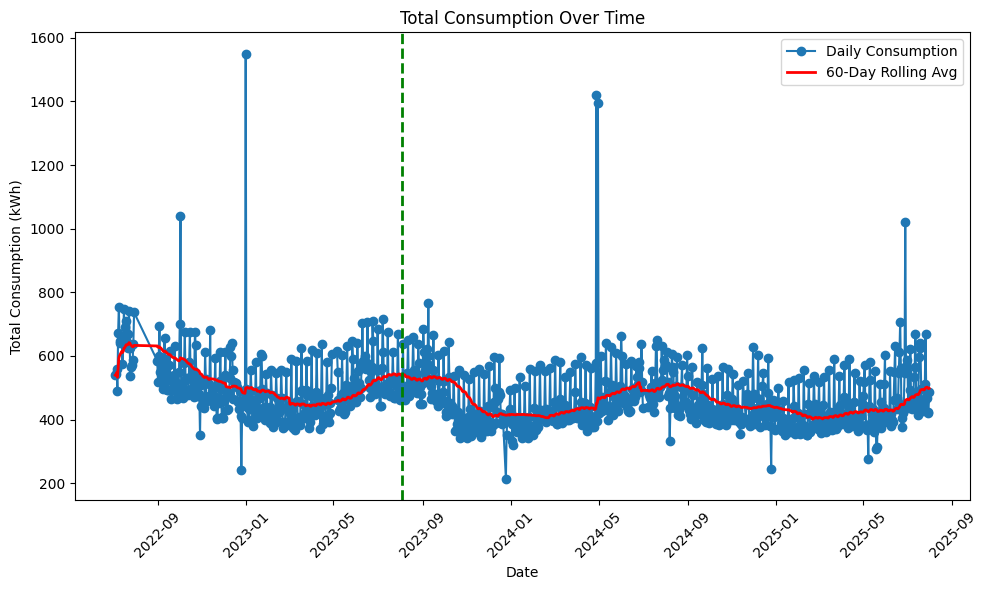

In [87]:
plt.figure(figsize=(10, 6))
plt.plot(energy_df["date"], energy_df['total_consumption_kwh'], marker='o', label='Daily Consumption')
# Calculate and plot 30-day rolling average
energy_df['rolling_avg'] = energy_df['total_consumption_kwh'].rolling(window=60, min_periods=1).mean()
plt.plot(energy_df["date"], energy_df['rolling_avg'], color='red', linewidth=2, label='60-Day Rolling Avg')
plt.xlabel('Date')
plt.ylabel('Total Consumption (kWh)')
plt.title('Total Consumption Over Time')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.axvline(dt.datetime(2023, 8, 3), color='green', linestyle='--', linewidth=2, label='03/08/2023')
plt.show()

zoom in plot to exclude the outliers

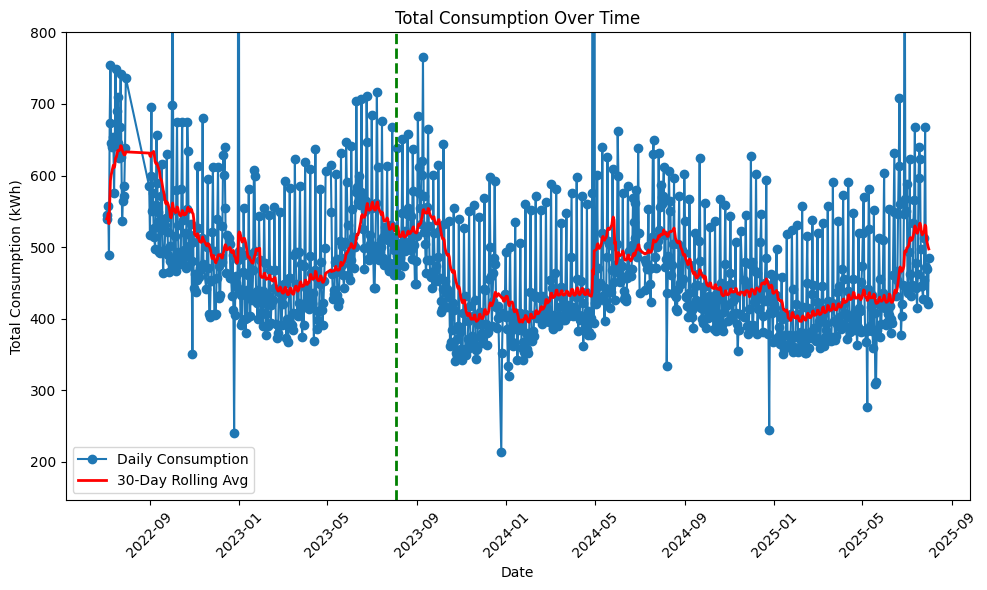

In [88]:
plt.figure(figsize=(10, 6))
plt.plot(energy_df["date"], energy_df['total_consumption_kwh'], marker='o', label='Daily Consumption')
# Calculate and plot 30-day rolling average
energy_df['consumption_rolling_avg'] = energy_df['total_consumption_kwh'].rolling(window=30, min_periods=1).mean()
plt.plot(energy_df["date"], energy_df['consumption_rolling_avg'], color='red', linewidth=2, label='30-Day Rolling Avg')
plt.xlabel('Date')
plt.ylabel('Total Consumption (kWh)')
plt.title('Total Consumption Over Time')
plt.ylim(top=800)
plt.xticks(rotation=45)
plt.legend()
plt.axvline(dt.datetime(2023, 8, 3), color='green', linestyle='--', linewidth=2, label='03/08/2023')
plt.tight_layout()
plt.show()

In [89]:
energy_df["year"] = energy_df["date"].dt.year
energy_df["month_name"]= energy_df["date"].dt.month_name()
energy_df["year_month"] = energy_df["date"].dt.strftime('%Y-%m')
energy_df["day_of_week"] = energy_df["date"].dt.day_name()
energy_df["day_no_of_week"] = energy_df["date"].dt.dayofweek


day_of_week
Monday       432.049020
Tuesday      428.901600
Wednesday    434.497255
Thursday     436.920710
Friday       480.305232
Saturday     592.908477
Sunday       477.766242
Name: total_consumption_kwh, dtype: float64


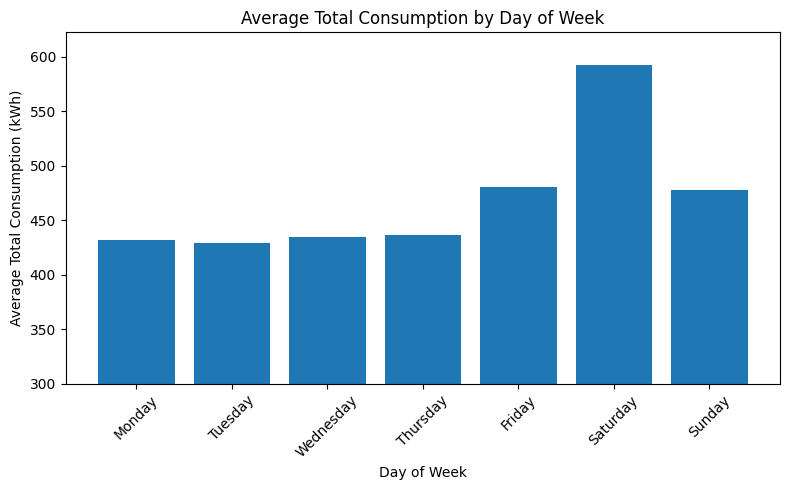

In [90]:
day_of_week_consumption = energy_df[energy_df["total_consumption_kwh"]<800].groupby("day_of_week")['total_consumption_kwh'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
print(day_of_week_consumption)
plt.figure(figsize=(8, 5))
plt.bar(day_of_week_consumption.index, day_of_week_consumption.values)
plt.xlabel('Day of Week')
plt.ylabel('Average Total Consumption (kWh)')
plt.title('Average Total Consumption by Day of Week')
plt.xticks(rotation=45)
plt.ylim(bottom=300)
plt.tight_layout()
plt.show()

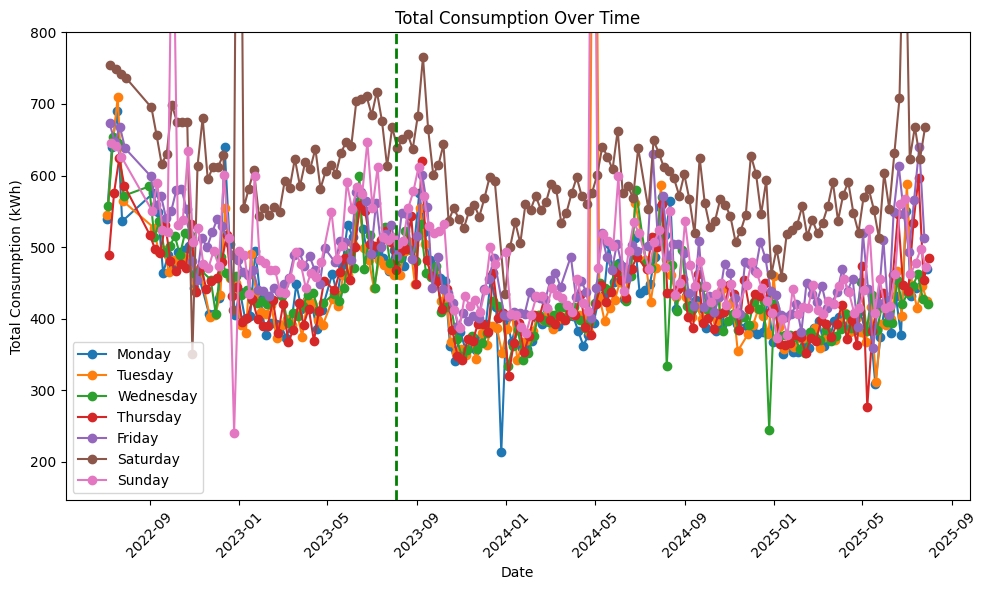

In [91]:
plt.figure(figsize=(10, 6))
for day in list(energy_df["day_of_week"].unique()):
    day_data = energy_df[energy_df["day_of_week"] == day]
    plt.plot(day_data["date"], day_data['total_consumption_kwh'], marker='o', label=day)
# Calculate and plot 30-day rolling average
energy_df['consumption_rolling_avg'] = energy_df['total_consumption_kwh'].rolling(window=30, min_periods=1).mean()
plt.xlabel('Date')
plt.ylabel('Total Consumption (kWh)')
plt.title('Total Consumption Over Time')
plt.ylim(top=800)
plt.xticks(rotation=45)
plt.legend()
plt.axvline(dt.datetime(2023, 8, 3), color='green', linestyle='--', linewidth=2, label='03/08/2023')
plt.tight_layout()
plt.show()

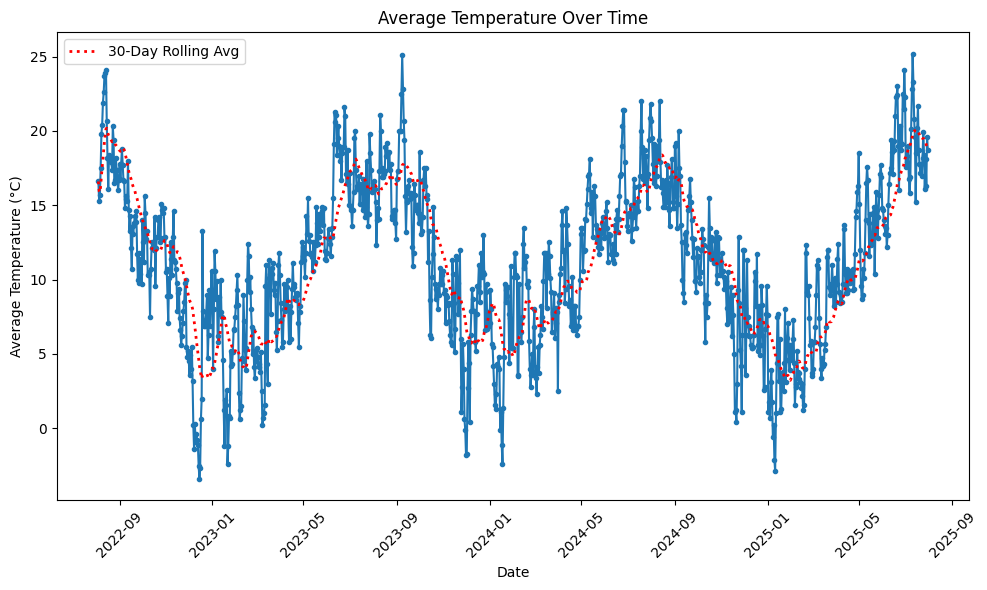

In [92]:
plt.figure(figsize=(10, 6))
plt.plot(temperature_df["date"], temperature_df['average_temperature'], marker='.')
# Calculate and plot 30-day rolling average
temperature_df['temp_rolling_avg'] = temperature_df['average_temperature'].rolling(window=30, min_periods=1).mean()
plt.plot(temperature_df["date"], temperature_df['temp_rolling_avg'], color='red', linewidth=2, label='30-Day Rolling Avg', linestyle=':')
plt.xlabel('Date')
plt.ylabel('Average Temperature (°C)')
plt.title('Average Temperature Over Time')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Merge Data

Merge both data frames together based on date. Use an inner join to avoid using dates with no temperature or energy data. 

In [93]:
merged_df = pd.merge(energy_df, temperature_df, on='date', how='inner')
display(merged_df.head(10))

,date,total_consumption_kwh,rolling_avg,consumption_rolling_avg,year,month_name,year_month,day_of_week,day_no_of_week,average_temperature,temp_rolling_avg
0,2022-08-31,584.81,631.373214,631.373214,2022,August,2022-08,Wednesday,2,16.7,18.721429
1,2022-09-01,516.87,627.424828,627.424828,2022,September,2022-09,Thursday,3,17.8,18.689655
2,2022-09-02,599.18,626.483333,626.483333,2022,September,2022-09,Friday,4,16.8,18.626667
3,2022-09-03,695.09,628.696452,631.666667,2022,September,2022-09,Saturday,5,17.8,18.666667
4,2022-09-04,550.79,626.261875,631.882667,2022,September,2022-09,Sunday,6,18.8,18.783333
5,2022-09-05,575.06,624.710303,632.450667,2022,September,2022-09,Monday,0,17.7,18.850000
6,2022-09-06,527.40,621.848235,633.729000,2022,September,2022-09,Tuesday,1,16.7,18.823333
7,2022-09-07,513.85,618.762571,628.434000,2022,September,2022-09,Wednesday,2,16.6,18.716667
8,2022-09-08,497.01,615.380556,619.841333,2022,September,2022-09,Thursday,3,14.8,18.530000
9,2022-09-09,558.20,613.835135,616.911000,2022,September,2022-09,Friday,4,15.4,18.313333


In [94]:
correlation = merged_df['total_consumption_kwh'].corr(merged_df['average_temperature'])
print("Correlation between Total Consumption and Average Temperature: {:.2f}".format(correlation))

Correlation between Total Consumption and Average Temperature: 0.35


## Feature Engineering
Additional date features were already created based on parts of the date. Impact of day of week on energy consumption has been analysed earlier which should be important in modelling energy consumption.

Create a boolean feature that defines if the site has underwent energy optimisation yet.

In [95]:
merged_df["is_optimised"] = merged_df["date"] >= dt.datetime(2023, 8, 3)

# Modelling

In [96]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder

In [100]:
enc = OneHotEncoder(sparse_output=False)
days_enc = enc.fit(merged_df[["day_of_week"]])
days_cols = days_enc.get_feature_names_out(["day_of_week"])
merged_df[days_cols] = days_enc.transform(merged_df[["day_of_week"]])
pre_optimisation_df = merged_df[merged_df["is_optimised"]==False]
post_optimisation_df = merged_df[merged_df["is_optimised"]==True]
X = pre_optimisation_df[["average_temperature"] + list(days_cols)]

y = pre_optimisation_df["total_consumption_kwh"]

,average_temperature,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,16.7,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,17.8,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,16.8,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,17.8,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,18.8,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [102]:
reg = LinearRegression().fit(X, y)
print("Coefficients: ", reg.coef_)

Coefficients:  [  5.42296176   3.2355707  -37.75909832 134.89612743  21.97752476
 -42.95517181 -46.02276429 -33.37218846]


In [103]:
X_predictions = post_optimisation_df[["average_temperature"] + list(days_cols)]
y_predictions = reg.predict(X_predictions)
post_optimisation_df["predicted_consumption_kwh"] = y_predictions


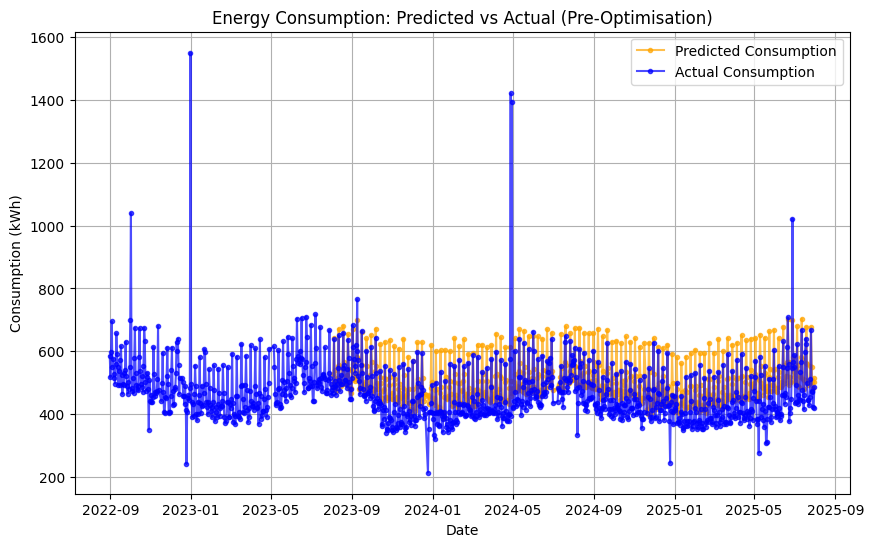

In [107]:
plt.figure(figsize=(10, 6))
plt.plot(post_optimisation_df["date"], post_optimisation_df['predicted_consumption_kwh'], marker='.', label='Predicted Consumption', color='orange',alpha=0.7)
plt.plot(merged_df["date"], merged_df['total_consumption_kwh'], marker='.', label='Actual Consumption', color='blue',alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Consumption (kWh)')
plt.title('Energy Consumption: Predicted vs Actual (Pre-Optimisation)')
plt.legend()
plt.grid(True)
plt.show()